# 09 — Souvisí `unknown` label s velikostí obce?

Hypotéza: čím menší obec (méně obyvatel), tím pravděpodobněji Wikipedia
extraktor vrátí `unknown` — malé obce mají kratší/chudší články, méně
jednoznačných vět o "se nachází"/"jsou obcí" apod.

`unknown` ≠ `not_found`/`error`: `unknown` znamená, že text byl nalezen a
zpracován, ale gramatické číslo z něj nešlo jednoznačně určit — je to jiná
kategorie chybovosti (viz CLAUDE.md).

**Dva doplňkové testy na stejná data**, ne jen jeden — z dobrého důvodu:

1. **Mann-Whitney U test** — nonparametrický test rozdílu dvou rozdělení
   (populace unknown vs. klasifikovaných obcí). Populace obcí je silně
   pravoúhlá/skewnutá (pár velkých měst, spousta malých vesnic) — Mann-Whitney
   nevyžaduje normalitu ani žádnou konkrétní funkční formu vztahu, jen testuje
   "mají tyhle dvě skupiny systematicky jiné rozdělení hodnot?". Bezpečný,
   nekontroverzní první krok.
2. **Logistická regrese** `is_unknown ~ log10(populace)` — kvantifikuje směr
   a *velikost* efektu (odds ratio), ne jen "existuje rozdíl?". Log-transformace
   populace je stejná konvence jako v `plot_population_logistic()` z nb07
   (populace je řádově rozložená, log dává lineárnější vztah k pravděpodobnosti).

Proč obojí: Mann-Whitney je robustnější (méně předpokladů), regrese je
informativnější (odhad efektu + CI). Pokud se shodnou, je závěr silnější;
pokud ne, rozdíl samotný je zajímavý (viz sekce 4).

In [1]:
import sys
from pathlib import Path

project_root = Path("..")
sys.path.insert(0, str(project_root / "src"))

import pandas as pd
import numpy as np
from scipy import stats

from geogram import viz, config

viz.set_style()

DATA = config.PROCESSED_DIR
WIKI_CSV = DATA / "ice_grammar_wiki_v2.csv"


## 1. Data

In [2]:
df = pd.read_csv(WIKI_CSV)
print(df["wiki_number"].value_counts())
print()
print(f"Chybí population_total: {df['population_total'].isna().sum()}")
print(f"population_total == 0: {(df['population_total'] == 0).sum()}")

wiki_number
plural      1410
singular     233
unknown      163
Name: count, dtype: int64

Chybí population_total: 0
population_total == 0: 1


## 2. Popisná statistika

Než testujeme, podíváme se, jestli je rozdíl vůbec vidět pouhým okem —
mediány a vizuální srovnání rozdělení.

Medián populace — unknown: 410, klasifikované: 470


C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\matplotlib\scale.py:375: RuntimeWarning: overflow encountered in exp
  return np.exp(values * np.log(self.base))
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\seaborn\distributions.py:488: RuntimeWarning: invalid value encountered in subtract
  widths = inv(edges + widths) - inv(edges)
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\seaborn\distributions.py:492: RuntimeWarning: invalid value encountered in multiply
  edges = edges + (1 - shrink) / 2 * widths
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_s

WindowsPath('C:/Users/dobes/Documents/UniversityCodingProject/NewFunnyProjects/GeoGram_sufix-ice/assets/img/geogram/09_population_histogram.png')

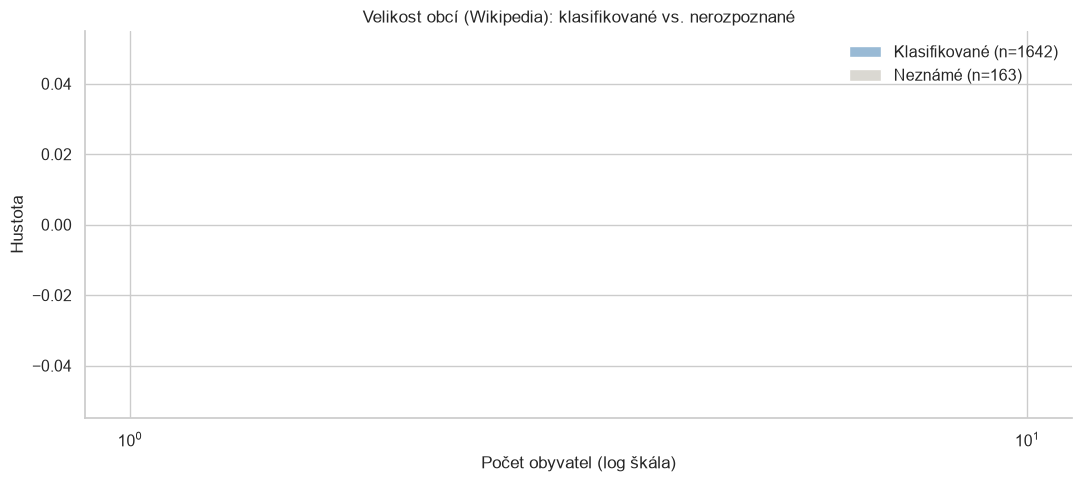

In [3]:
d = df[df["wiki_number"].isin(["singular", "plural", "unknown"])].dropna(subset=["population_total"])
d = d[d["population_total"] > 0]

med_unknown = d.loc[d["wiki_number"] == "unknown", "population_total"].median()
med_classified = d.loc[d["wiki_number"] != "unknown", "population_total"].median()
print(f"Medián populace — unknown: {med_unknown:.0f}, klasifikované: {med_classified:.0f}")

fig = viz.plot_missing_analysis(df)
viz.save_fig(fig, "09_population_histogram")

## 3. Statistické testy

In [4]:
result = viz.test_unknown_population(df)

print(f"n = {result['n']} obcí ({result['n_unknown']} unknown)")
print()
print("--- Mann-Whitney U test (H1: populace unknown < populace klasifikovaných) ---")
print(f"U = {result['mannwhitney_u']:.0f}, p = {result['mannwhitney_p']:.4f}")
print(f"medián populace unknown: {result['median_pop_unknown']:.0f}")
print(f"medián populace klasifikovaných: {result['median_pop_classified']:.0f}")
print()
print("--- Logistická regrese: is_unknown ~ log10(populace) ---")
print(f"beta (log10 populace) = {result['logit_coef']:.4f}, p = {result['logit_p']:.4f}")
print(f"odds ratio na 10x populaci = {result['logit_odds_ratio_per_10x_pop']:.3f}")
print(f"95% CI odds ratio = ({result['logit_ci_odds_ratio'][0]:.3f}, {result['logit_ci_odds_ratio'][1]:.3f})")
print(f"pseudo R^2 (McFadden) = {result['logit_pseudo_r2']:.4f}")

n = 1805 obcí (163 unknown)

--- Mann-Whitney U test (H1: populace unknown < populace klasifikovaných) ---
U = 124584, p = 0.0728
medián populace unknown: 410
medián populace klasifikovaných: 470

--- Logistická regrese: is_unknown ~ log10(populace) ---
beta (log10 populace) = -0.3592, p = 0.0452
odds ratio na 10x populaci = 0.698
95% CI odds ratio = (0.491, 0.992)
pseudo R^2 (McFadden) = 0.0037


C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:885: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:885: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:40: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.savefig(path, dpi=config.DPI_SAVE, bbox_inches="tight")
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:40: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.savefig(path, dpi=config.DPI_SAVE, bbox_inches="tight")


                           Logit Regression Results                           
Dep. Variable:             is_unknown   No. Observations:                 1805
Model:                          Logit   Df Residuals:                     1803
Method:                           MLE   Df Model:                            1
Date:                Sat, 11 Jul 2026   Pseudo R-squ.:                0.003746
Time:                        10:42:18   Log-Likelihood:                -545.30
converged:                       True   LL-Null:                       -547.35
Covariance Type:            nonrobust   LLR p-value:                   0.04286
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -1.3542      0.479     -2.829      0.005      -2.292      -0.416
population_total    -0.3592      0.179     -2.002      0.045      -0.711      -0.008


C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  func(*args, **kwargs)
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  func(*args, **kwargs)


C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


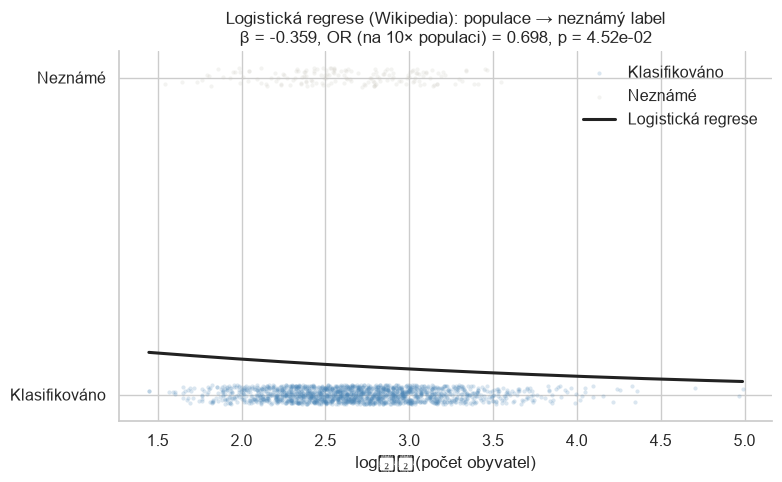

In [5]:
fig, logit_result = viz.plot_unknown_population_logistic(df)
viz.save_fig(fig, "09_unknown_population_logistic")
print(logit_result.summary())

## 4. Kde na ose populace leží unknown? (srovnání všech 3 labelů)

Sekce 3 se ptala "P(unknown | populace)" a slučovala singulár+plurál do jedné
"klasifikované" skupiny (kvůli logistické regresi na binární proměnné). Jenže
plurál (1410 obcí) a singulár (233 obcí) v té skupině nemají stejnou váhu na
to, jak vypadá — pokud se singulár a plurál sami mezi sebou liší velikostí,
sloučení je "rozmělní" a signál z porovnání s unknown se ztratí.

Zde se ptáme jinak: **kde na diskrétní ose populace leží unknown ve srovnání
se všemi třemi labely zvlášť** — je jen dole, nebo rozprostřené jako ostatní?
Tři vizualizace stejné otázky + jeden omnibus test:

C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:933: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([f"{_LABEL_TITLES[c]}\n(n={ns.get(c, 0)})" for c in _LABEL_ORDER])
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:939: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:939: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:40: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.

WindowsPath('C:/Users/dobes/Documents/UniversityCodingProject/NewFunnyProjects/GeoGram_sufix-ice/assets/img/geogram/09_population_boxplot_by_label.png')

C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  func(*args, **kwargs)
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  func(*args, **kwargs)


C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


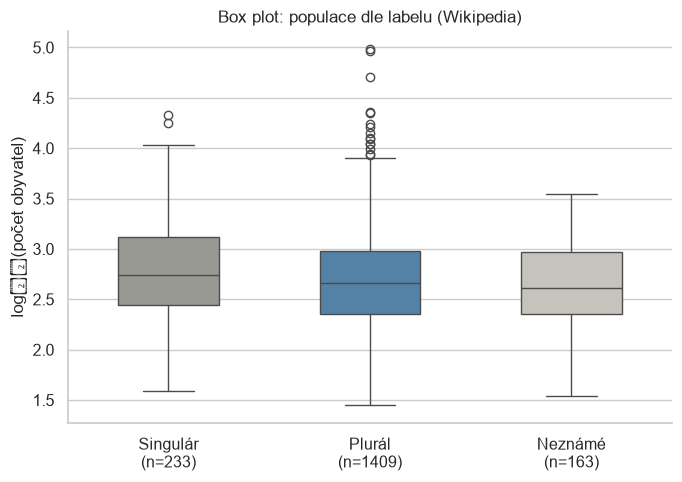

In [6]:
fig = viz.plot_population_by_label(df, kind="box")
viz.save_fig(fig, "09_population_boxplot_by_label")

Boxplot dá nejrychlejší přehled o mediánech a rozptylu, ale se silně
nevyrovnanými skupinami (1410 vs. 233 vs. 163) může "kopeček" hustoty
prozradit víc — třeba bimodalitu, kterou box/whiskery skryjí.

C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:972: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:972: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:40: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.savefig(path, dpi=config.DPI_SAVE, bbox_inches="tight")
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:40: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.savefig(path, dpi=config.DPI_SAVE, bbox_inches="tight")


WindowsPath('C:/Users/dobes/Documents/UniversityCodingProject/NewFunnyProjects/GeoGram_sufix-ice/assets/img/geogram/09_population_density_by_label.png')

C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  func(*args, **kwargs)
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  func(*args, **kwargs)


C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


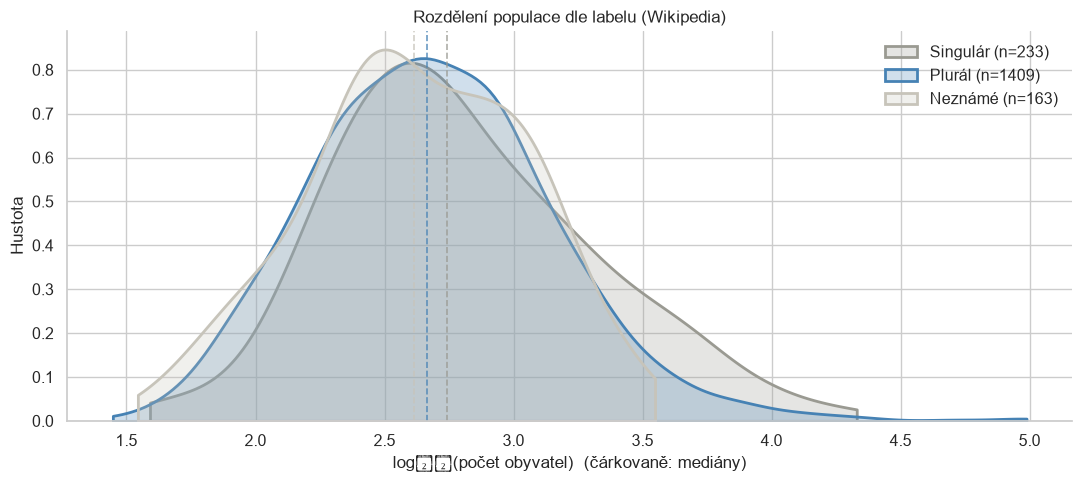

In [7]:
fig = viz.plot_population_density_by_label(df)
viz.save_fig(fig, "09_population_density_by_label")

**ECDF (empirická distribuční funkce)** — třetí pohled, tentokrát přímo
navázaný na statistický test: Mann-Whitney U vlastně testuje přesně rozdíl
mezi křivkami ECDF (stochastickou dominanci). Pokud křivka unknown leží
nad ostatními, znamená to, že při libovolné hranici populace X má unknown
skupina vyšší podíl obcí pod touto hranicí — tedy je systematicky menší.

C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:1003: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:1003: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:40: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.savefig(path, dpi=config.DPI_SAVE, bbox_inches="tight")
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:40: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.savefig(path, dpi=config.DPI_SAVE, bbox_inches="tight")


WindowsPath('C:/Users/dobes/Documents/UniversityCodingProject/NewFunnyProjects/GeoGram_sufix-ice/assets/img/geogram/09_population_ecdf_by_label.png')

C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  func(*args, **kwargs)
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  func(*args, **kwargs)


C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


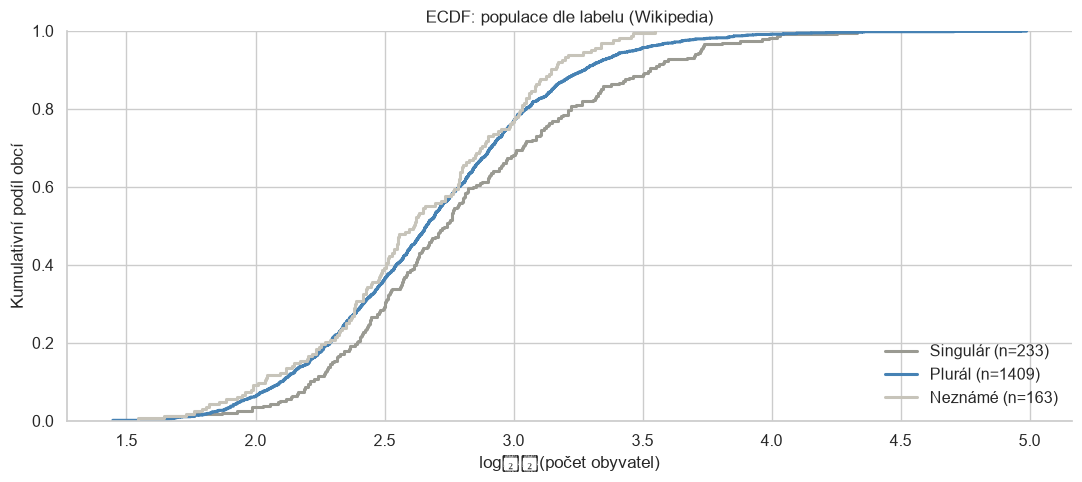

In [8]:
fig = viz.plot_population_ecdf_by_label(df)
viz.save_fig(fig, "09_population_ecdf_by_label")

### Test: Kruskal-Wallis (omnibus) + párové Mann-Whitney

Kruskal-Wallis je nonparametrická obdoba ANOVA pro 3+ skupin — testuje, jestli
se rozdělení populace liší napříč všemi třemi labely najednou, bez předpokladu
normality. Pokud vyjde významně, teprve pak má smysl ptát se, KTERÁ dvojice
se liší — párové Mann-Whitney s Bonferroniho korekcí (×3 srovnání), aby se
násobným testováním neinflovala chyba I. druhu.

In [9]:
t3 = viz.test_population_by_label(df)

print(f"n = {t3['n']}")
print(f"mediány populace: singulár={t3['medians']['singular']:.0f}, "
      f"plurál={t3['medians']['plural']:.0f}, unknown={t3['medians']['unknown']:.0f}")
print()
print(f"Kruskal-Wallis: H = {t3['kruskal_h']:.2f}, p = {t3['kruskal_p']:.4f}")
print()
print("Párové Mann-Whitney (Bonferroni-korigované, x3):")
for pair, r in t3["pairwise"].items():
    sig = "*" if r["p_bonferroni"] < 0.05 else " "
    print(f"  {sig} {pair:24s} medián {r['median_a']:.0f} vs {r['median_b']:.0f} "
          f"  p_raw={r['p_raw']:.4f}  p_bonf={r['p_bonferroni']:.4f}")

n = 1805
mediány populace: singulár=551, plurál=460, unknown=410

Kruskal-Wallis: H = 10.95, p = 0.0042

Párové Mann-Whitney (Bonferroni-korigované, x3):
  * singular_vs_plural       medián 551 vs 460   p_raw=0.0030  p_bonf=0.0091
  * singular_vs_unknown      medián 551 vs 410   p_raw=0.0030  p_bonf=0.0091
    plural_vs_unknown        medián 460 vs 410   p_raw=0.2811  p_bonf=0.8434


**Zjištění, které binární test v sekci 3 skryl:** Kruskal-Wallis je významný
(H ≈ 10.9, p ≈ 0.004) — populace se napříč třemi labely neliší náhodně. Ale
párové srovnání ukazuje, že hnací silou **není** rozdíl plurál vs. unknown
(p_bonf ≈ 0.84, žádný rozdíl) — je to **singulár**, kdo je systematicky
větší než obě ostatní skupiny (singulár medián 551 vs. plurál 460, p_bonf ≈
0.009; singulár vs. unknown 551 vs. 410, p_bonf ≈ 0.009). Unknown a plurál
mají prakticky stejné rozdělení populace.

Jinými slovy: signál "menší obce → unknown", který v sekci 3 vyšel jako
formálně významný (ale slabý, p ≈ 0.045) na binárním srovnání, je ve
skutečnosti z větší části artefakt toho, že **singulár** (menšinová
kategorie, jen 233 obcí) je typicky větší obce (viz i logistická regrese v
nb07 — singulár koreluje s velikostí i tam) — a když se singulár smíchá s
plurálem do "klasifikované" skupiny, natáhne jí medián nahoru, takže rozdíl
proti unknown vypadá výrazněji, než odpovídá realitě mezi unknown a plurálem
samotným (kde skutečný rozdíl je zanedbatelný, p_bonf ≈ 0.84).

## 5. Celková interpretace

**Výsledek je slabý a na hraně významnosti — poctivě to takhle i podat.**

- **Mann-Whitney U:** p = 0.073, tedy **nevýznamný** na obvyklé hladině 0.05
  (medián populace unknown 410 vs. klasifikované 470 — rozdíl je v očekávaném
  směru, ale ne dost silný na to, aby ho nonparametrický test bez dalších
  předpokladů odlišil od šumu).
- **Logistická regrese:** p = 0.045, tedy **formálně významná** (odds ratio na
  10x populaci = 0.698, 95% CI (0.491, 0.992) — těsně nepřekračuje 1).
  Ale pseudo R² (McFadden) = 0.0037 — populace vysvětluje jen zlomek procenta
  variance v `unknown`. Efekt je reálný, ale prakticky velmi slabý.

**Proč se testy rozcházejí:** Mann-Whitney testuje celé rozdělení bez modelu,
logistická regrese využívá spojitou informaci (log-populaci) a je tak citlivější
na malý, ale konzistentní posun — cena za to je, že spoléhá na správnou funkční
formu (lineární vztah v log-škále). 95% CI odds ratio končí na 0.992, těsně pod
1.0 — tohle je typický "hraniční" case, kde by nezávislá replikace na jiném
vzorku (např. až přibudou IJP data) měla rozhodnout, jestli je efekt skutečný.

**Závěr pro projekt:** existuje slabý náznak, že menší obce mají o něco vyšší
šanci na `unknown`, ale efekt není dost silný na to, aby zásadně zkresloval
závěry v nb07 — McFadden R² pod 0.01 znamená, že drtivá většina variance v
`unknown` je dána něčím jiným (kvalita/délka Wikipedia článku, ne populace
samotná). Nejde o důkaz silného missing-not-at-random mechanismu, spíš o
mírný trend, který stojí za zmínku jako limitaci, ne za přepočítávání
výsledků s váhováním.

**Doplnění ze sekce 4 (3-skupinové srovnání):** binární test (unknown vs.
"klasifikované") o slabém efektu (p ≈ 0.045, McFadden R² ≈ 0.004) je z větší
části tažen tím, že singulár — ne unknown — je ta neobvyklá skupina co do
velikosti obce. Přímé srovnání unknown vs. plurál (jediná skutečně
"velká" dvojice v datech, 1410 vs. 163 obcí) nevyšlo významné vůbec
(p_bonf ≈ 0.84). Závěr z nb07 (podíl sg/pl po vyloučení unknown) tím zůstává
v pohodě — riziko zkreslení velikostí obce je ještě menší, než naznačoval
binární test samotný.